In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading Dataset & Data Overview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_excel(
    '/content/drive/MyDrive/Project 1: Credit Risk/Credit risk (1).xlsx',
    sheet_name='credit_risk_dataset',
)
df.head().T

,0,1,2,3,4
person_age,22,21,25,23,24
person_income,59000,9600,9600,65500,54400
person_home_ownership,RENT,OWN,MORTGAGE,RENT,RENT
person_emp_length,123.0,5.0,1.0,4.0,8.0
loan_intent,PERSONAL,EDUCATION,MEDICAL,MEDICAL,MEDICAL
loan_grade,D,B,C,C,C
loan_amnt,35000,1000,5500,35000,35000
loan_int_rate,16.02,11.14,12.87,15.23,14.27
loan_status,1,0,1,1,1
loan_percent_income,0.59,0.1,0.57,0.53,0.55


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


## Data Pre-pocessing

1. Missing Values & Duplicates
2. Outlier Detection
3. Target Variable Balance



1. Missing Values & Duplicates



In [4]:
df_clean = df

In [5]:
df_clean.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [6]:
df_clean.duplicated().sum()

np.int64(165)

In [7]:
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)

(32416, 12)


2. Outlier Detection

In [8]:
df['person_age'].describe()


,person_age
count,32581.000000
mean,27.734600
std,6.348078
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


In [9]:
df['person_emp_length'].describe()

,person_emp_length
count,32581.000000
mean,4.960558
std,4.209948
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [10]:
df.sort_values('person_age', ascending=False).head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,11.01,0,0.26,N,4
32416,94,24000,RENT,1.0,MEDICAL,C,6500,11.01,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24
32422,80,64000,RENT,7.0,MEDICAL,B,6800,11.71,0,0.11,N,25
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32534,76,75000,RENT,23.0,MEDICAL,A,15000,8.94,0,0.20,N,25


In [11]:
df.sort_values('person_emp_length', ascending=False).head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32515,53,106000,MORTGAGE,38.0,PERSONAL,B,20000,9.88,0,0.19,N,23
32428,58,49000,MORTGAGE,34.0,MEDICAL,D,7500,13.55,1,0.15,Y,24
30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,9000,14.54,0,0.13,N,17
31866,47,178000,OWN,31.0,VENTURE,B,9000,10.99,0,0.05,N,17
32263,46,180000,MORTGAGE,31.0,MEDICAL,B,18000,9.91,0,0.10,N,12
31867,46,180000,MORTGAGE,31.0,VENTURE,B,18000,9.91,0,0.10,N,11
32562,61,160000,MORTGAGE,30.0,PERSONAL,B,24000,10.38,0,0.15,N,21


In [12]:
# Checking for overlap between the two broken-row sets
age_outliers = df[df['person_age'] > 100]
emp_outliers = df[df['person_emp_length'] > 100]
overlap = age_outliers.index.intersection(emp_outliers.index)
print(overlap)

Index([], dtype='int64')


In [13]:
# Filter condition
df_clean = df_clean[~((df_clean['person_age'] > 100) | (df_clean['person_emp_length'] > 60))].copy()

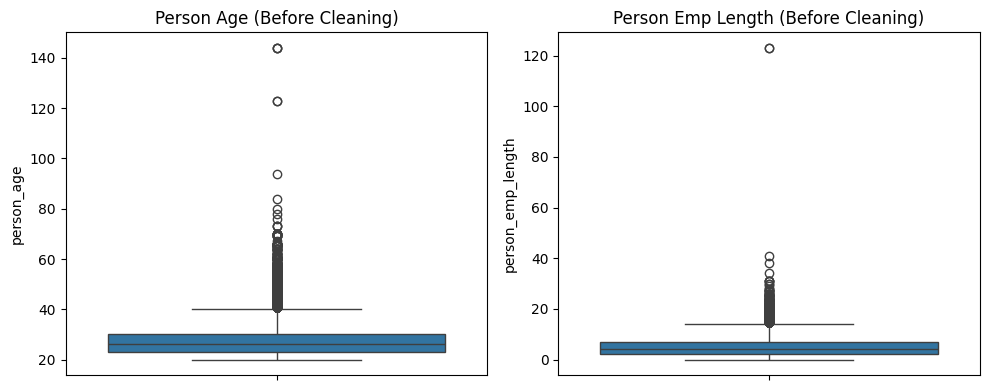

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(y=df['person_age'], ax=axes[0])
axes[0].set_title("Person Age (Before Cleaning)")
sns.boxplot(y=df['person_emp_length'], ax=axes[1])
axes[1].set_title("Person Emp Length (Before Cleaning)")
plt.tight_layout()
plt.show()

In [15]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (32581, 12)
After: (32409, 12)


In [16]:
df_clean['person_age'].describe()

,person_age
count,32409.000000
mean,27.730754
std,6.210445
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,94.000000


In [17]:
df_clean['person_emp_length'].describe()

,person_emp_length
count,32409.000000
mean,4.953281
std,4.109293
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


In [18]:
df_clean.sort_values('person_income', ascending=False).head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0,0.00,Y,15
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,11.01,0,0.00,N,21
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0,0.00,N,15
31922,47,1362000,MORTGAGE,9.0,VENTURE,A,6600,7.74,0,0.00,N,17
29119,36,1200000,OWN,16.0,MEDICAL,A,10000,6.54,0,0.01,N,11
29120,40,1200000,MORTGAGE,1.0,MEDICAL,A,10000,11.01,0,0.01,N,16
17833,32,1200000,MORTGAGE,1.0,VENTURE,A,12000,7.51,0,0.01,N,8
17834,34,948000,MORTGAGE,18.0,PERSONAL,B,2000,9.99,0,0.00,N,7
32298,58,900000,RENT,18.0,DEBTCONSOLIDATION,C,19600,13.98,0,0.02,N,28


In [19]:
print((df_clean['person_income'] > 500000).sum())
print((df_clean['person_income'] > 1000000).sum())

51
8


3. Target Variable Balance

In [20]:
df_clean['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0,0.781295
1,0.218705


In [21]:
df_clean.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.953281,9592.486655,11.016421,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,4.109293,6320.885127,3.083094,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.010000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Explore and Visualize the Clean Dataset

Summary Statistics

In [22]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                 'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent',
                     'loan_grade', 'cb_person_default_on_file']

summary_stats = df_clean[numeric_cols].describe().T[["mean", "50%", "std", "min", "max"]]
summary_stats = summary_stats.rename(columns={"50%": "median", "std": "standard deviation"})
summary_stats.round(2)

,mean,median,standard deviation,min,max
person_age,27.73,26.00,6.21,20.00,94.00
person_income,65894.28,55000.00,52517.87,4000.00,2039784.00
person_emp_length,4.95,4.00,4.11,0.00,41.00
loan_amnt,9592.49,8000.00,6320.89,500.00,35000.00
loan_int_rate,11.02,11.01,3.08,5.42,23.22
loan_percent_income,0.17,0.15,0.11,0.00,0.83
cb_person_cred_hist_length,5.81,4.00,4.06,2.00,30.00


## Distribution charts

1. Numerical Distribution Charts
2. Categorical Distribution Charts




1. Numerical Distribution Charts



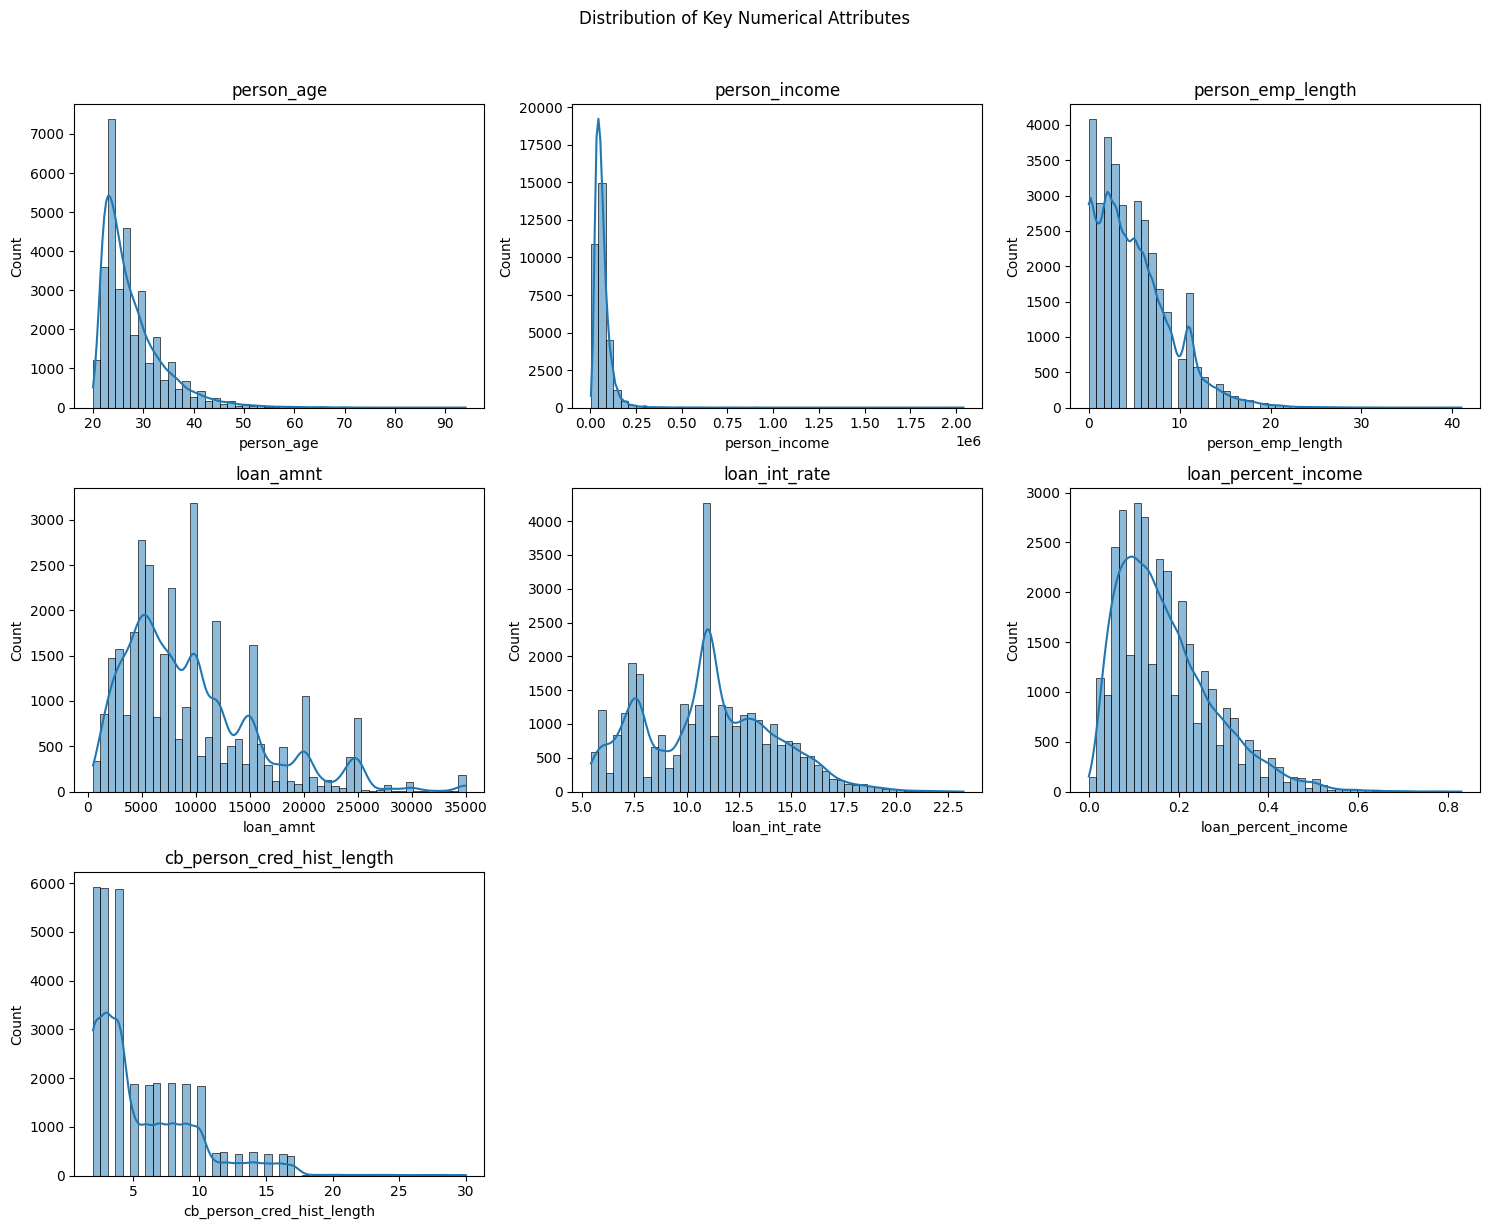

In [23]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Key Numerical Attributes", y=1.02)
plt.tight_layout()
plt.show()

2. Categorical Distribution Charts


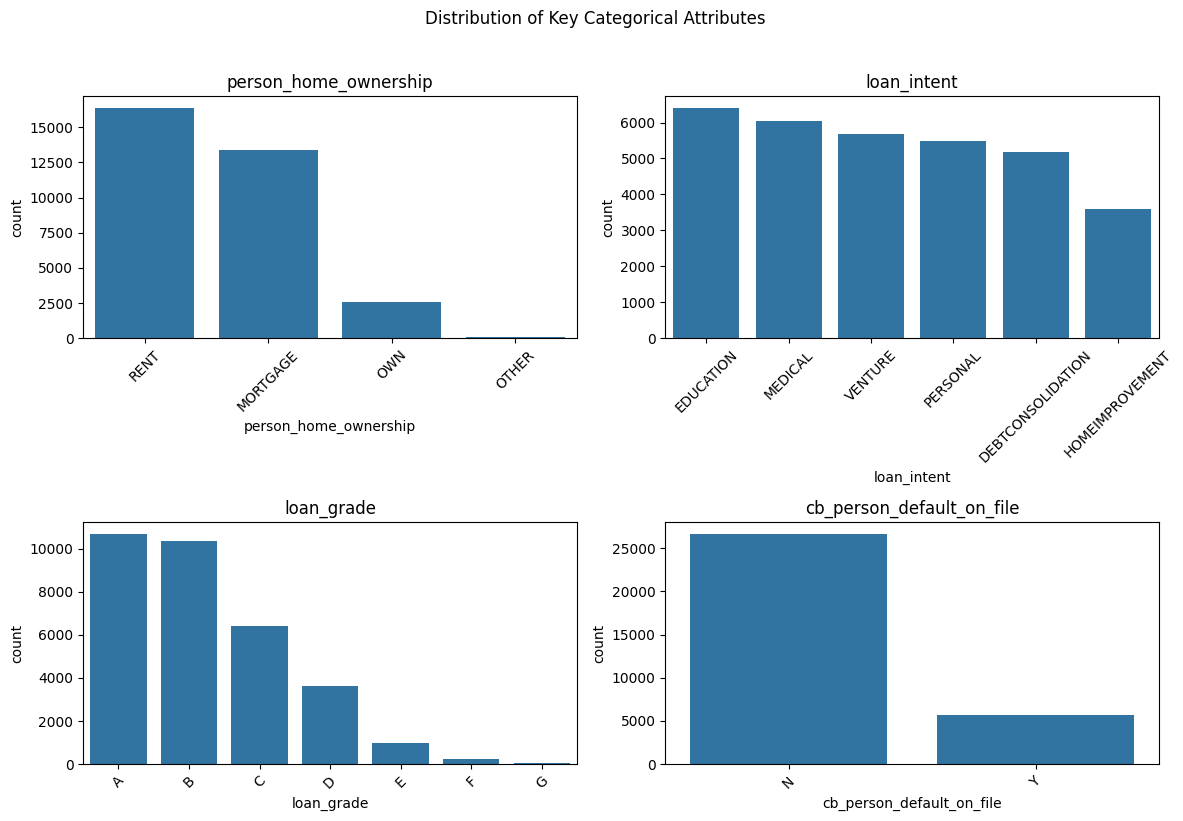

In [24]:
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df_clean, ax=axes[i],
                   order=df_clean[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Key Categorical Attributes", y=1.02)
plt.tight_layout()
plt.show()

 ## Multivariate Analysis

1. Correlation Analysis
2. Two Categorical Variables vs Count
3. Aggregation Analysis (Mean vs Median)
4. How Loan Income Affect Default Rate (Average and Variation)


1. Correlation Analysis

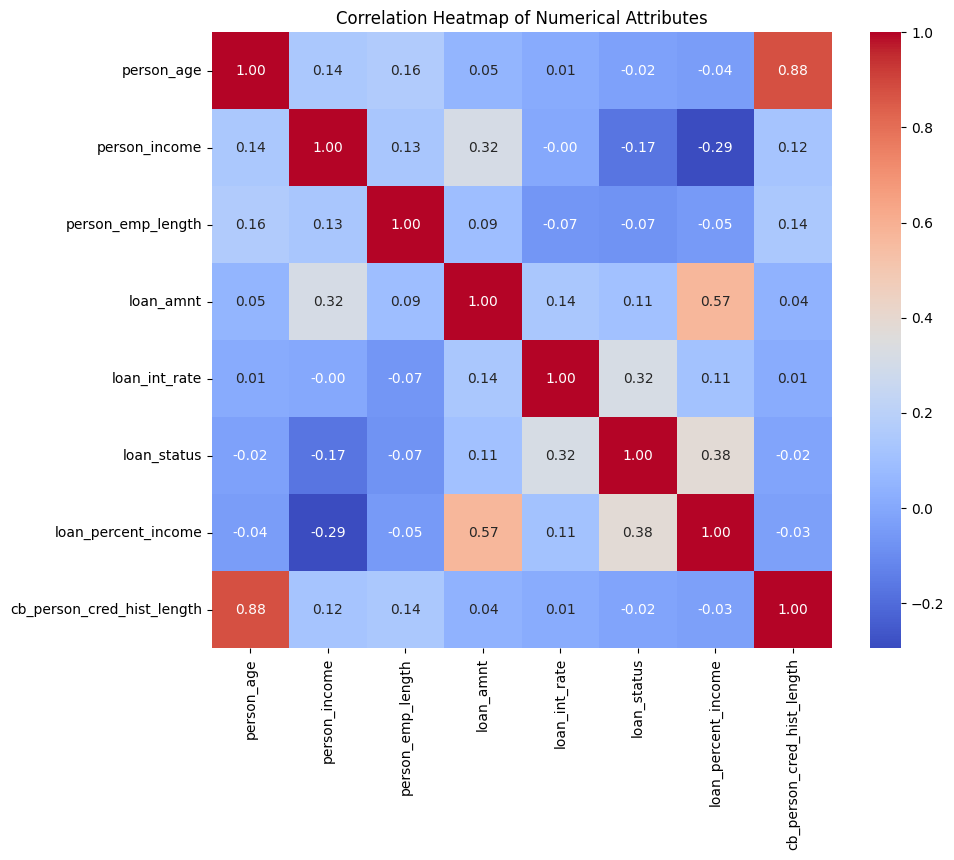

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Attributes")
plt.show()

2. Two Categorical Variables vs Count


In [26]:
table_a = df_clean.groupby(['loan_grade', 'cb_person_default_on_file']).size().reset_index(name='count')
print(table_a)


   loan_grade cb_person_default_on_file  count
0           A                         N  10702
1           B                         N  10384
2           C                         N   3191
3           C                         Y   3245
4           D                         N   1747
5           D                         Y   1872
6           E                         N    499
7           E                         Y    464
8           F                         N    129
9           F                         Y    112
10          G                         N     28
11          G                         Y     36


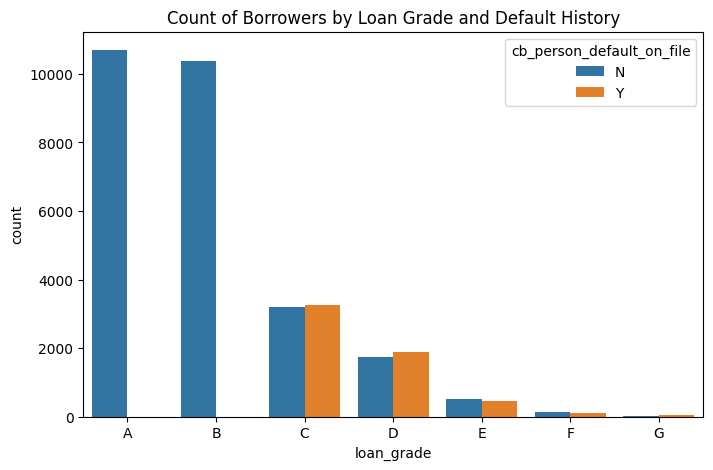

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='loan_grade', hue='cb_person_default_on_file', data=df_clean,
              order=sorted(df_clean['loan_grade'].unique()))
plt.title("Count of Borrowers by Loan Grade and Default History")
plt.show()

3. Aggregation Analysis (Mean & Median)

  person_home_ownership       mean  median       std
0              MORTGAGE  10.545967   10.99  3.137969
1                 OTHER  11.903774   11.58  2.492388
2                   OWN  10.877710   11.01  3.114949
3                  RENT  11.416419   11.01  2.978251


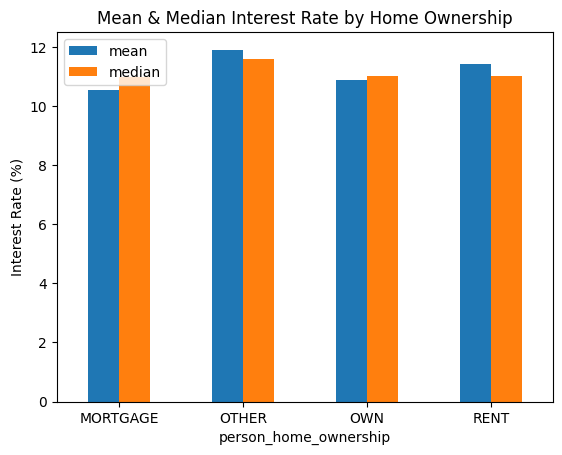

In [28]:
table_b = df_clean.groupby('person_home_ownership')['loan_int_rate'].agg(['mean', 'median', 'std']).reset_index()
print(table_b)

table_b.set_index('person_home_ownership')[['mean','median']].plot(kind='bar')
plt.title("Mean & Median Interest Rate by Home Ownership")
plt.ylabel("Interest Rate (%)")
plt.xticks(rotation=0)
plt.show()

4. How Loan Income Affect Default Rate (Average and Variation)

  pct_income_bin      mean       std
0     [0.0, 0.1)  0.115903  0.320127
1     [0.1, 0.2)  0.147411  0.354529
2     [0.2, 0.3)  0.209758  0.407166
3     [0.3, 0.4)  0.619291  0.485644
4     [0.4, 0.5)  0.725451  0.446511
5     [0.5, 0.6)  0.773723  0.419186
6     [0.6, 0.7)  0.729167  0.449093
7     [0.7, 0.8)  0.818182  0.404520


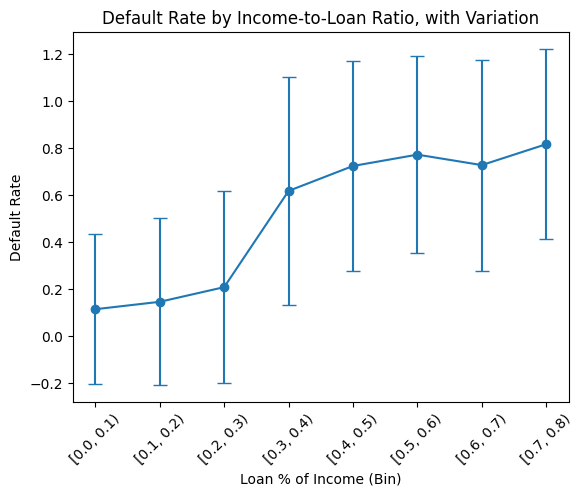

In [29]:
bins1 = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
df_clean['pct_income_bin'] = pd.cut(df_clean['loan_percent_income'], bins=bins1, right=False)

table_4d = df_clean.groupby('pct_income_bin', observed=True)['loan_status'].agg(['mean','std']).reset_index()
print(table_4d)

plt.errorbar(table_4d['pct_income_bin'].astype(str), table_4d['mean'], yerr=table_4d['std'],
             fmt='o-', capsize=5)
plt.title("Default Rate by Income-to-Loan Ratio, with Variation")
plt.xlabel("Loan % of Income (Bin)")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

##Featuring Engineering

1. Log Transformation of person_income
2. Encoding Categorical Variables



In [30]:
import numpy as np

df_clean['person_income_log'] = np.log1p(df_clean['person_income'])

In [31]:
df_clean[['person_age', 'person_income', 'person_emp_length',
          'loan_amnt', 'loan_int_rate', 'loan_percent_income',
          'cb_person_cred_hist_length']].skew()

,0
person_age,1.942359
person_income,9.777874
person_emp_length,1.123425
loan_amnt,1.191489
loan_int_rate,0.218448
loan_percent_income,1.063283
cb_person_cred_hist_length,1.657991


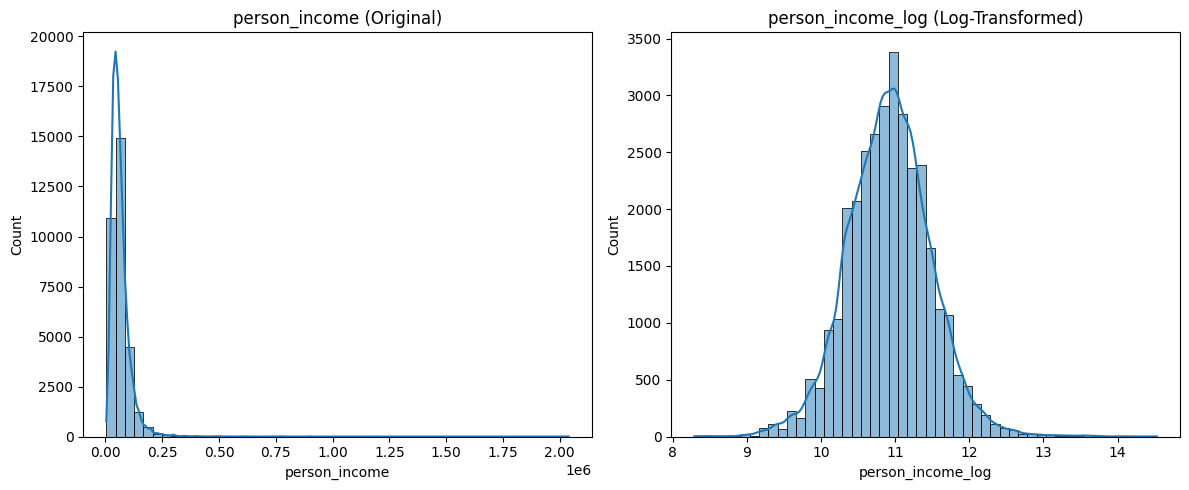

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df_clean['person_income'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("person_income (Original)")
sns.histplot(df_clean['person_income_log'], bins=50, kde=True, ax=axes[1])
axes[1].set_title("person_income_log (Log-Transformed)")
plt.tight_layout()
plt.show()

2. Encoding Categorical Variables

In [33]:
# Ordinal encoding for loan_grade (has a natural order A-G)
grade_order = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df_clean['loan_grade_encoded'] = df_clean['loan_grade'].map(grade_order)

df_clean[['loan_grade', 'loan_grade_encoded']].drop_duplicates().sort_values('loan_grade_encoded')

,loan_grade,loan_grade_encoded
5,A,0
1,B,1
2,C,2
9,D,3
13,E,4
17,F,5
448,G,6


In [34]:
# Binary encoding for cb_person_default_on_file
df_clean['default_on_file_encoded'] = df_clean['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

df_clean[['cb_person_default_on_file', 'default_on_file_encoded']].drop_duplicates()

,cb_person_default_on_file,default_on_file_encoded
1,N,0
4,Y,1


In [35]:
# One-hot encoding for loan_intent and home_ownership
df_clean = pd.get_dummies(df_clean, columns=['loan_intent', 'person_home_ownership'], drop_first=True)

In [36]:
df_clean[['loan_intent_EDUCATION', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL',
          'loan_intent_VENTURE', 'loan_intent_HOMEIMPROVEMENT']].head()

,loan_intent_EDUCATION,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_intent_HOMEIMPROVEMENT
1,True,False,False,False,False
2,False,True,False,False,False
3,False,True,False,False,False
4,False,True,False,False,False
5,False,False,False,True,False


In [37]:
# drop person_age
df_clean = df_clean.drop(columns=['person_age'])
df_clean.columns.tolist()

['person_income',
 'person_emp_length',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length',
 'pct_income_bin',
 'person_income_log',
 'loan_grade_encoded',
 'default_on_file_encoded',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT']

In [38]:
# Drop columns no longer needed for modeling
df_model = df_clean.drop(columns=[
    'loan_grade',                    # replaced by loan_grade_encoded
    'cb_person_default_on_file',     # replaced by default_on_file_encoded
    'person_income',                 # replaced by person_income_log
    'pct_income_bin'                 # was only for EDA binning, not a real feature
])

df_model.columns.tolist()

['person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'person_income_log',
 'loan_grade_encoded',
 'default_on_file_encoded',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT']

Train shape: (25927, 16)
Test shape: (6482, 16)
Accuracy: 0.8509719222462203


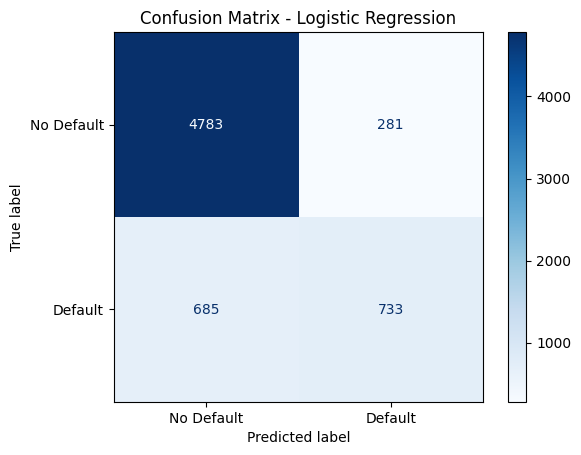

              precision    recall  f1-score   support

           0       0.87      0.94      0.91      5064
           1       0.72      0.52      0.60      1418

    accuracy                           0.85      6482
   macro avg       0.80      0.73      0.76      6482
weighted avg       0.84      0.85      0.84      6482



In [39]:
# --- Feature/Target Split ---
X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

# --- Train/Test Split ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# --- Feature Scaling ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Train Logistic Regression ---
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# --- Predictions ---
y_pred = log_reg.predict(X_test_scaled)

# --- Accuracy ---
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --- Classification Report ---
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [40]:
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

In [41]:
print("=== Original Model ===")
print(classification_report(y_test, y_pred))

print("=== Balanced Model ===")
print(classification_report(y_test, y_pred_balanced))

=== Original Model ===
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      5064
           1       0.72      0.52      0.60      1418

    accuracy                           0.85      6482
   macro avg       0.80      0.73      0.76      6482
weighted avg       0.84      0.85      0.84      6482

=== Balanced Model ===
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5064
           1       0.51      0.79      0.62      1418

    accuracy                           0.79      6482
   macro avg       0.72      0.79      0.74      6482
weighted avg       0.84      0.79      0.80      6482

